# 04 · Simulated discovery

Reads only `results/04_discovery/` (run records written by `experiments/04_discovery.py`,
tables by `experiments/04_evaluate.py`); nothing is fitted and no API is called here. Every
number is printed from those files.

Each run starts from 50 random non-target materials and does 20 rounds: fit on the measured
materials, score the rest, measure the 10 best. Targets: the top 1% of Tc in the pool (main) or
among non-cuprates (hard).

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

D = Path("../results/04_discovery")
FIG = D / "figures"
summary = pd.read_csv(D / "summary.csv")

## 1. Pilot decision and gates
The pilot (seeds 100-102) chose between EI and q90 by a rule fixed in advance. The gates had to
pass before any main-run request; none of them looks at which method finds more.

In [2]:
display(json.loads((D / "pilot_decision.json").read_text()))
gates = json.loads((D / "gates.json").read_text())
{k: v["pass"] if isinstance(v, dict) else v for k, v in gates.items()}

{'totals': {'ei': 441, 'q90': 378},
 'tie': False,
 'chosen': ['ei'],
 'rule': 'more targets found by the last round summed over pilot runs; within max(1, 10% of the larger total) keeps both',
 'per_run_found': {'ei': [112, 90, 96, 59, 62, 22],
  'q90': [86, 89, 84, 66, 1, 52]},
 'seeds': [100, 101, 102],
 'rounds': 20,
 'decided_at': '2026-10-02T21:14:44+00:00'}

{'G1_pilot_complete': True,
 'G3_batches_from_unlabeled': True,
 'G2_random_vs_exact': True,
 'G4_budget_authorizes_main': True,
 'all_pass': True,
 'checked_at': '2026-10-02T21:15:55+00:00',
 'final_main_integrity': True}

In [3]:
display(json.loads((D / "grid_check.json").read_text()))

{'pool': 15097,
 'train': 50,
 'y_star_K': 116.3,
 'threshold_K': 119.0,
 'grid_levels': {'tail': 146, 'u999': 999},
 'request_seconds': {'tail': 8.400581624999177, 'u999': 34.74380754199956},
 'mean_max_abs_diff_K': 0.0,
 'ei': {'max_abs_diff': 0.0048536001241719084,
  'median_abs_diff': 9.091634664454284e-05,
  'mean_tail': 0.3383821005902149,
  'mean_999': 0.3383082388462358,
  'spearman': 0.999993952922674,
  'same_first_batch': 10,
  'batch': 10},
 'q90': {'max_abs_diff': 0.006851638351861311,
  'median_abs_diff': 0.0003758867780234709,
  'mean_tail': 53.199691331346294,
  'mean_999': 53.19988334390055,
  'spearman': 0.9999999977811032,
  'same_first_batch': 10,
  'batch': 10},
 'p_top1': {'max_abs_diff': 0.00024927028533083817,
  'median_abs_diff': 4.94135113493499e-07,
  'mean_tail': 0.011852234195445274,
  'mean_999': 0.011846441514994036,
  'spearman': 0.9999896949264522,
  'same_first_batch': 10,
  'batch': 10}}

## 2. Targets found (main runs, 10 seeds)

,scenario,acquisition,targets_in_pool,found_50,found_100,found_200,found_200_lo,found_200_hi,random_200,enrichment_200,first_hit_median,runs_without_hit,random_expected_first_hit
0,hard,ei,79,5.7,20.8,53.9,42.35,65.45,2.08,25.88,37.0,0,94.85
1,hard,greedy_tabpfn,79,5.7,14.9,26.7,4.70,48.70,2.08,12.82,72.5,2,94.85
2,hard,greedy_xgb,79,10.0,23.9,33.6,9.97,57.23,2.08,16.13,27.0,3,94.85
3,hard,random,79,0.7,1.1,2.3,0.87,3.73,2.08,1.10,46.0,1,94.85
4,main,ei,152,10.3,30.3,79.6,65.20,94.00,2.01,39.53,20.0,0,98.68
5,main,greedy_tabpfn,152,10.7,25.7,42.5,16.23,68.77,2.01,21.11,6.0,3,98.68
6,main,greedy_xgb,152,15.3,27.1,35.6,11.52,59.68,2.01,17.68,2.0,3,98.68
7,main,random,152,0.4,1.2,2.1,1.24,2.96,2.01,1.04,60.0,0,98.68


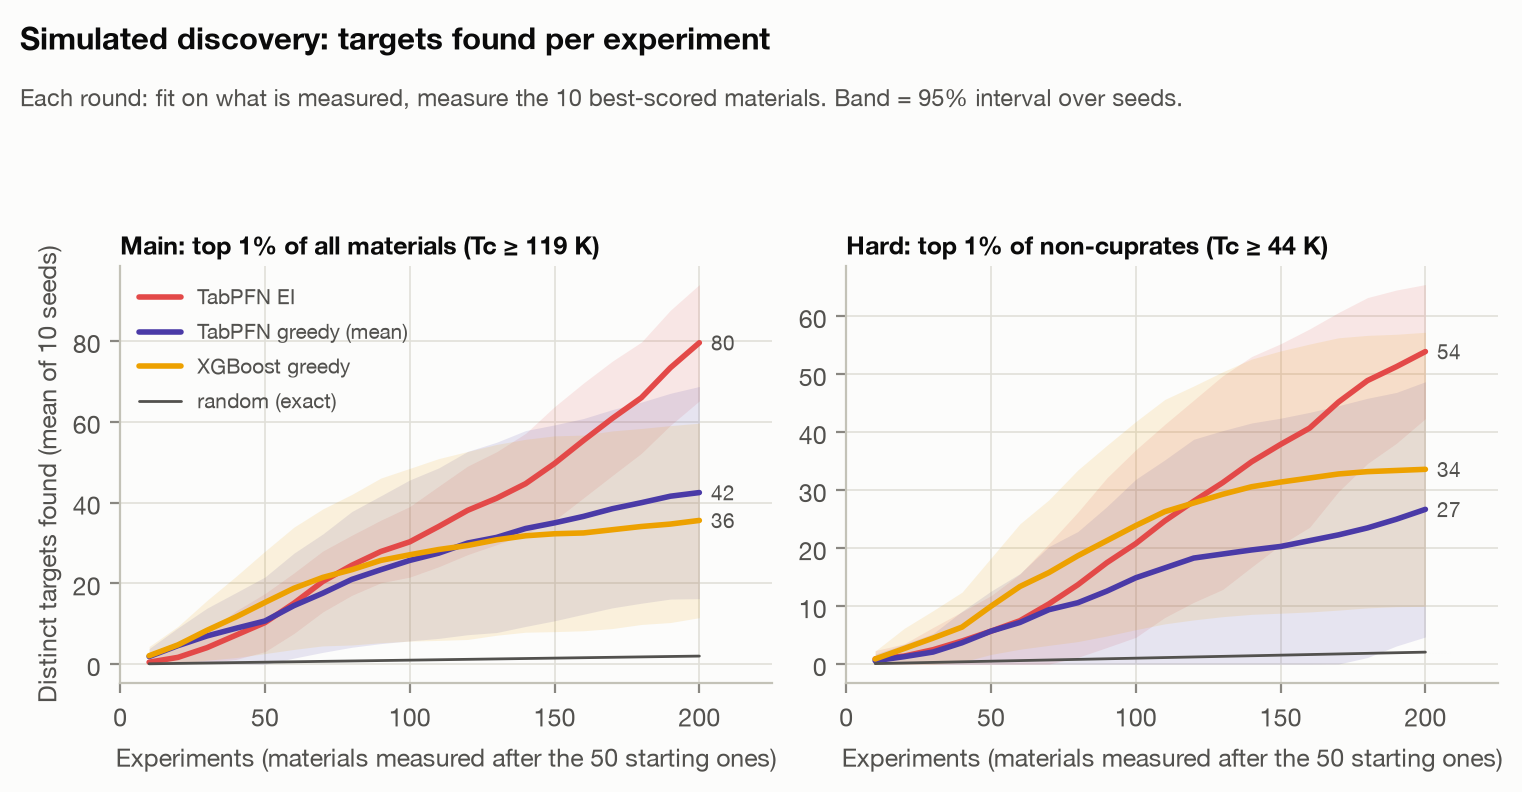

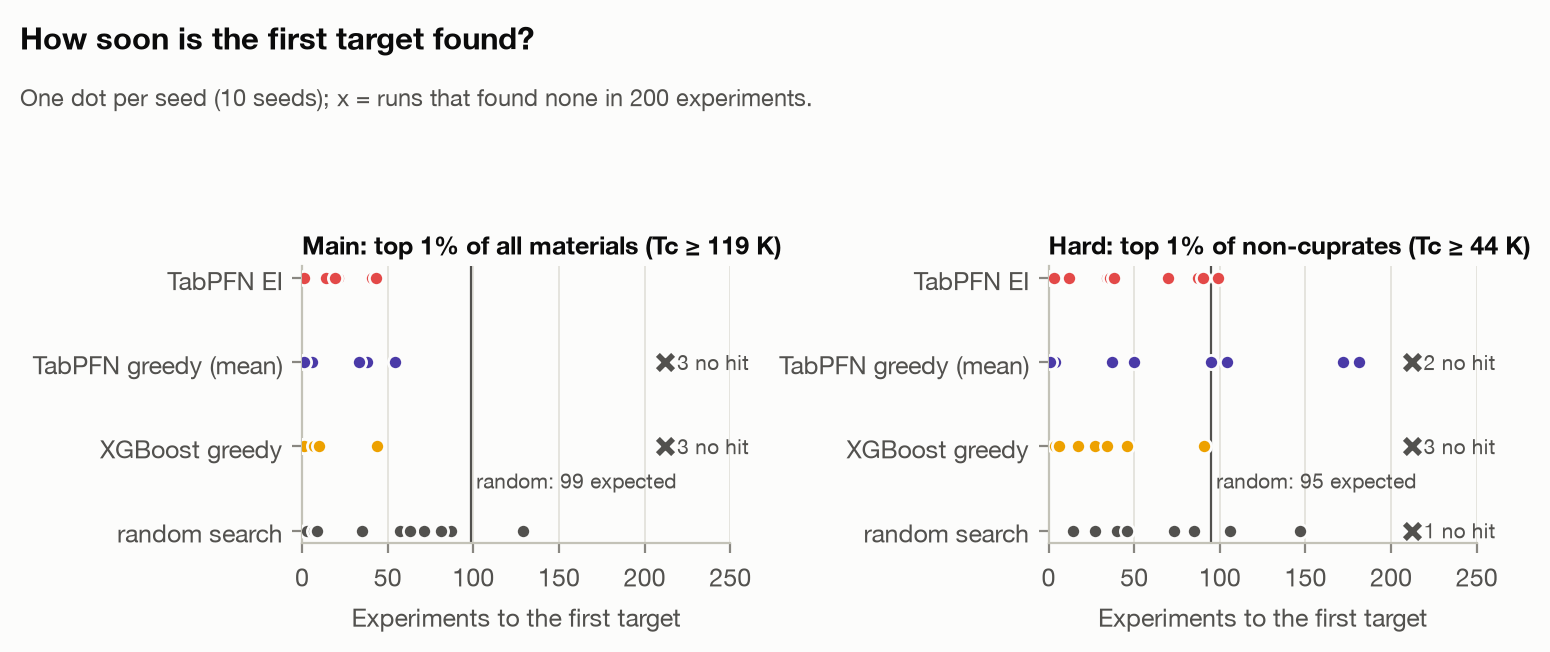

In [4]:
cols = [
    "scenario",
    "acquisition",
    "targets_in_pool",
    "found_50",
    "found_100",
    "found_200",
    "found_200_lo",
    "found_200_hi",
    "random_200",
    "enrichment_200",
    "first_hit_median",
    "runs_without_hit",
    "random_expected_first_hit",
]
display(summary[summary.phase == "main"][cols].round(2))
display(Image(FIG / "discovery_curves.png"))
display(Image(FIG / "first_hit.png"))

## 3. Paired by seed: EI vs every other method (targets found after 200 experiments)

In [5]:
pd.read_csv(D / "paired.csv").round(2)

,phase,scenario,a,b,seeds,mean_diff,diff_lo,diff_hi,a_better,b_better,ties
0,main,main,ei,greedy_tabpfn,10,37.1,6.62,67.58,9,1,0
1,main,main,ei,greedy_xgb,10,44.0,17.83,70.17,9,1,0
2,main,main,ei,random,10,77.5,63.44,91.56,10,0,0
3,main,hard,ei,greedy_tabpfn,10,27.2,7.40,47.00,7,3,0
4,main,hard,ei,greedy_xgb,10,20.3,0.54,40.06,6,3,1
5,main,hard,ei,random,10,51.6,40.50,62.70,10,0,0


## 4. How new were the targets found?
L1 distance (over element fractions) from each found target to the nearest material already
measured when it was picked, and whether it was only an oxygen variant of a measured one.

,phase,scenario,acquisition,targets_found,share_within_l1_0.01,share_within_l1_0.05,share_beyond_l1_0.1,share_oxygen_variant_of_labeled,median_nn_l1
0,main,hard,ei,539,0.056,0.275,0.555,0.121,0.122
1,main,hard,greedy_tabpfn,267,0.071,0.296,0.513,0.116,0.105
2,main,hard,greedy_xgb,336,0.074,0.339,0.405,0.155,0.063
3,main,hard,random,23,0.000,0.087,0.870,0.044,0.215
4,main,main,ei,796,0.093,0.495,0.340,0.112,0.051
5,main,main,greedy_tabpfn,425,0.096,0.506,0.306,0.092,0.049
6,main,main,greedy_xgb,356,0.104,0.542,0.301,0.079,0.044
7,main,main,random,21,0.000,0.190,0.762,0.000,0.328


,phase,scenario,acquisition,family,targets_found
0,main,hard,ei,iron-based,538
1,main,hard,ei,other,1
2,main,hard,greedy_tabpfn,iron-based,267
3,main,hard,greedy_xgb,iron-based,336
4,main,hard,random,iron-based,23
5,main,main,ei,cuprate,796
6,main,main,greedy_tabpfn,cuprate,425
7,main,main,greedy_xgb,cuprate,356
8,main,main,random,cuprate,21


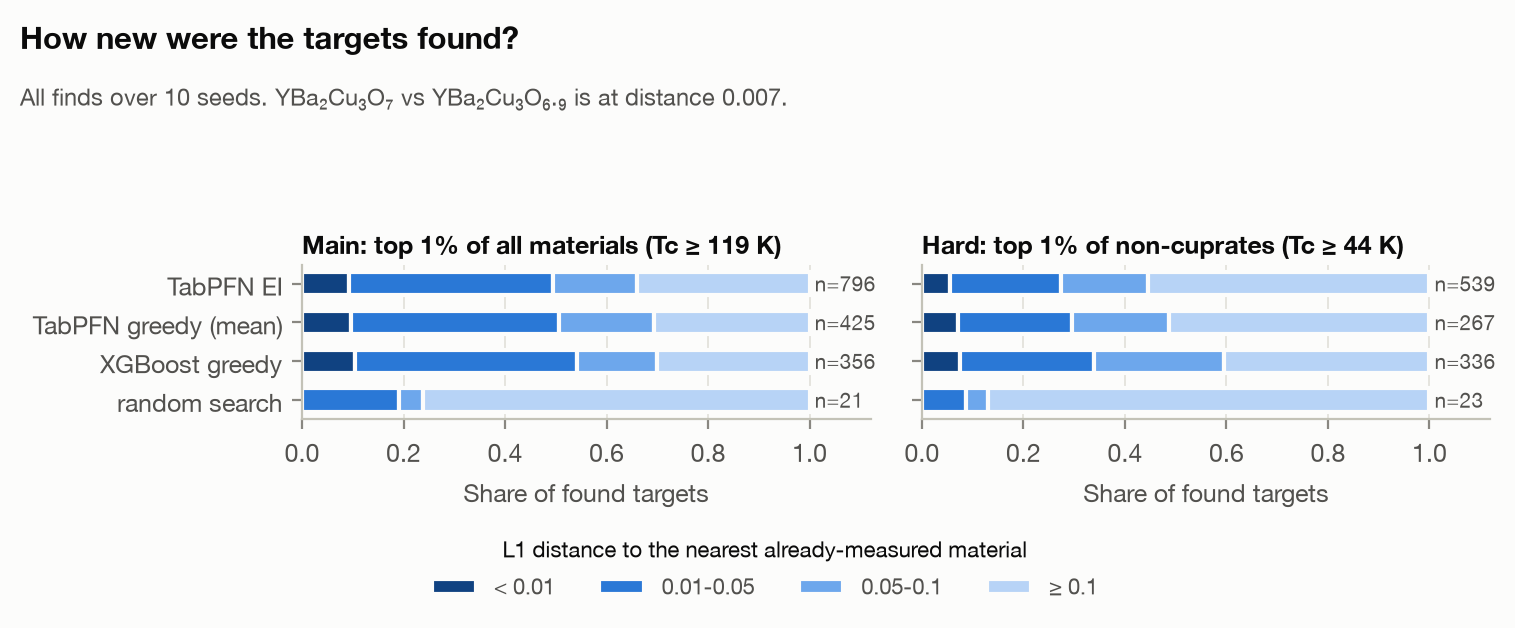

In [6]:
nov = pd.read_csv(D / "novelty.csv")
display(nov[nov.phase == "main"].round(3))
display(pd.read_csv(D / "families.csv").query("phase == 'main'"))
display(Image(FIG / "novelty.png"))

## 5. Are TabPFN's probabilities reliable during discovery?

,phase,scenario,acquisition,expected_targets,found_targets,expected_above_77K,found_above_77K
0,main,hard,ei,575.3,539,7.4,0
1,main,hard,greedy_tabpfn,258.5,267,3.8,0
2,main,main,ei,761.6,796,1567.1,1568
3,main,main,greedy_tabpfn,446.5,425,1871.9,1865
4,pilot,hard,ei,128.4,143,3.0,0
5,pilot,hard,q90,135.2,119,1.9,0
6,pilot,main,ei,311.0,298,538.6,528
7,pilot,main,q90,274.6,259,550.5,545


,phase,scenario,acquisition,p_lo,p_hi,n,predicted,observed
0,main,hard,ei,0.000,0.001,333731,0.0006,0.0027
1,main,hard,ei,0.001,0.005,667223,0.0024,0.0039
2,main,hard,ei,0.005,0.010,207415,0.0071,0.0057
3,main,hard,ei,0.010,0.020,140008,0.0139,0.0098
4,main,hard,ei,0.020,0.050,90945,0.0306,0.0187
5,main,hard,ei,0.050,0.100,33337,0.0695,0.0227
6,main,hard,ei,0.100,0.200,15553,0.1397,0.0566
7,main,hard,ei,0.200,0.500,8885,0.3019,0.1694
8,main,hard,ei,0.500,1.000,1303,0.6074,0.4421
18,main,main,ei,0.000,0.001,1056881,0.0006,0.0000


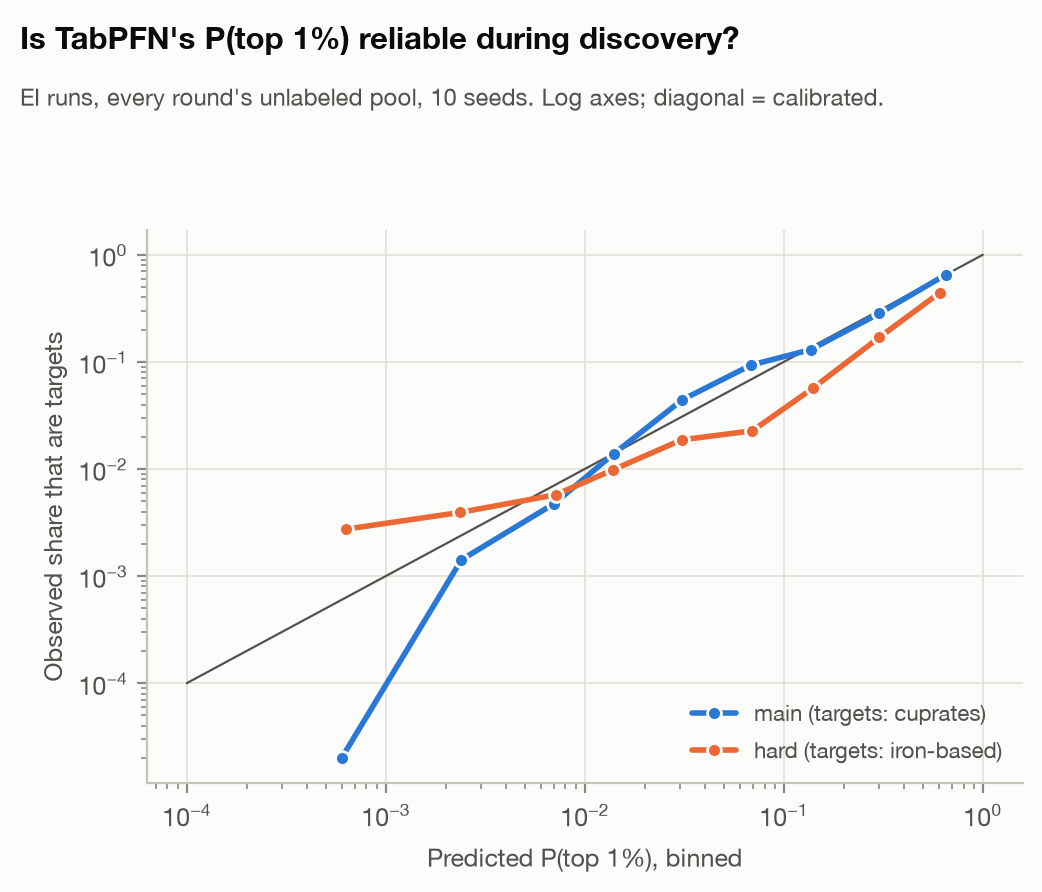

In [7]:
display(pd.read_csv(D / "batch_calibration.csv").round(1))
rel = pd.read_csv(D / "reliability.csv")
display(rel[(rel.phase == "main") & (rel.acquisition == "ei")].round(4))
display(Image(FIG / "reliability.png"))

## 6. Pilot runs (seeds 100-102), for completeness

In [8]:
summary[summary.phase == "pilot"][cols].round(2)

,scenario,acquisition,targets_in_pool,found_50,found_100,found_200,found_200_lo,found_200_hi,random_200,enrichment_200,first_hit_median,runs_without_hit,random_expected_first_hit
8,hard,ei,79,0.00,1.33,47.67,-7.68,103.01,2.08,22.89,73.0,0,94.85
9,hard,greedy_xgb,79,9.67,17.67,22.00,-72.66,116.66,2.08,10.56,6.0,2,94.85
10,hard,q90,79,3.00,14.33,39.67,-45.32,124.65,2.08,19.05,51.0,0,94.85
11,hard,random,79,0.33,1.33,2.67,-1.13,6.46,2.08,1.28,56.0,0,94.85
12,main,ei,152,16.33,42.33,99.33,71.08,127.58,2.01,49.33,16.0,0,98.68
13,main,greedy_xgb,152,6.00,20.33,49.00,2.99,95.01,2.01,24.33,8.0,0,98.68
14,main,q90,152,16.33,41.67,86.33,80.08,92.58,2.01,42.87,6.0,0,98.68
15,main,random,152,0.33,0.67,1.00,-1.48,3.48,2.01,0.50,93.0,1,98.68


In [9]:
json.loads((D / "timing.json").read_text())

{'hard': {'requests': 520, 'median_s': 7.6, 'p95_s': 12.1, 'total_h': 1.4655},
 'main': {'requests': 520,
  'median_s': 11.45,
  'p95_s': 16.004999999999995,
  'total_h': 1.856277777777778}}